# 06. 모델 학습 v2 — Log Base 정규화 (실험 3, 기각됨)

실험 1(MinMaxScaler)의 후속으로 Log Base 정규화와 장기 Anchor-Positive 전략을 적용한 학습 실험이다. 정량 지표는 개선됐지만 시각적 유사도가 낮아 최종적으로 기각됐다.

## 실험 개요

| 항목 | 실험 1 (patron_03, 채택) | 실험 3 (patron_07/08, 기각) |
|------|--------------------------|------------------------------|
| 정규화 | MinMaxScaler per window | Log Base: log(P_t / P_0) |
| Anchor-Positive | +1/+2/+3주 (3쌍) | +6/+12주 (2쌍) |
| Semi-hard 시작 | Epoch 3 | Epoch 2 |
| Sample Size | 3 | 5 |
| 최대 Epoch | 3 | 10 (patience 3) |
| 총 학습 시간 | ~6.5시간 | ~8시간 |

## 학습 결과

| Epoch | Train Loss | Val Loss | 비고 |
|-------|------------|----------|------|
| 1 | 0.162128 | 0.149140 | Best 저장, Random Mining |
| 2 | 0.133942 | 0.166153 | Semi-hard 시작 |
| 3 | 0.111511 | **0.138237** | Best 저장 (최종) |
| 4 | 0.076978 | 0.154244 | |
| 5 | 0.028457 | 0.154916 | |
| 6 | 0.029692 | 0.144096 | Early Stop (patience 3) |

**Best Val Loss: 0.138237** (실험 1 대비 27배 높음 — 정규화 스케일 차이)

## 기각 이유

정량 지표(중복 종목 수 0.15개, 평균 L2 거리 0.061)는 실험 1보다 우수했으나, 시각적 비교에서 쿼리 패턴과 다른 형태의 차트가 검색되는 사례가 다수 확인돼 실험 1을 최종 채택했다.

## 1. 라이브러리 임포트

PyTorch, torchvision, sklearn 등 학습에 필요한 라이브러리를 불러온다. Mixed Precision 학습을 위한 `autocast`와 `GradScaler`도 함께 임포트한다. 실험 1과 동일한 환경을 사용한다.

In [1]:
import numpy as np
import pandas as pd
import os
import gc
import time
import warnings
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import models

# 시각화
import matplotlib.pyplot as plt

# Google Colab
from google.colab import drive

warnings.filterwarnings('ignore')

print("✅ 라이브러리 임포트 완료")
print(f"✅ PyTorch 버전: {torch.__version__}")
print(f"✅ CUDA 사용 가능: {torch.cuda.is_available()}")

✅ 라이브러리 임포트 완료
✅ PyTorch 버전: 2.8.0+cu126
✅ CUDA 사용 가능: True


Google Drive를 마운트하고 v2 전용 데이터 경로를 설정한다. 이미지는 I/O 속도를 위해 Colab 로컬 저장소에서 읽고, 학습 결과(체크포인트, 그래프)는 Google Drive에 보관한다.

images_v2.tar를 Google Drive에서 Colab 로컬로 복사하고 압축 해제한다. Drive 직접 읽기 대비 I/O 속도가 약 100배 빠르며, 이는 Semi-hard Mining처럼 Epoch 내에서 개별 이미지를 반복 로딩하는 방식에서 특히 중요하다.

## 2. 경로 설정 및 데이터 복사

이미지 아카이브를 로컬로 복사하고 압축 해제한다. 실험 3은 Log 정규화된 이미지를 사용하므로 `data_v2/images_v2` 경로를 별도로 관리한다.

사용 가능한 GPU를 확인하고 이름과 메모리를 출력한다. A100 40GB 기준 Epoch당 약 48분이 소요되며, 이후 GPU 캐시를 초기화해 모델 초기화 전 깨끗한 상태를 확보한다.

In [2]:
# Google Drive 마운트
drive.mount('/content/drive')

# 경로 설정
GDRIVE_BASE = '/content/drive/MyDrive/Patron'
COLAB_STORAGE = '/content/data_v2'

# 데이터 경로
GDRIVE_DATA_V2 = f'{GDRIVE_BASE}/data_v2'
IMAGE_DIR = f'{COLAB_STORAGE}/images_v2'  # 코랩 저장소 (빠름!)
PROCESSED_PATH = f'{COLAB_STORAGE}/processed_v2'

# 모델 저장 경로
MODEL_SAVE_PATH = f'{GDRIVE_BASE}/models_v2'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("="*60)
print("📁 경로 설정 (v2)")
print("="*60)
print(f"✅ 구글 드라이브 데이터: {GDRIVE_DATA_V2}")
print(f"✅ 코랩 저장소 Images: {IMAGE_DIR}")
print(f"✅ 모델 저장: {MODEL_SAVE_PATH}")
print("="*60)

Mounted at /content/drive
📁 경로 설정 (v2)
✅ 구글 드라이브 데이터: /content/drive/MyDrive/Patron/data_v2
✅ 코랩 저장소 Images: /content/data_v2/images_v2
✅ 모델 저장: /content/drive/MyDrive/Patron/models_v2


## 3. Anchor-Positive 쌍 생성 (v2 전략)

실험 1의 +1/+2/+3주 전략 대신 **+6주, +12주**만 Positive로 사용한다. 더 먼 미래 패턴을 같은 종목으로 묶어 단기 가격 노이즈를 줄이고 장기 추세 특징을 학습하려는 의도다. 총 **93,094쌍**이 생성된다.

In [3]:
# images_v2.tar 복사 및 압축 해제
print("📦 이미지 데이터 복사 중...")

# tar 파일 복사 (구글 드라이브 → 코랩 저장소)
!mkdir -p {COLAB_STORAGE}
!cp {GDRIVE_DATA_V2}/images_v2.tar {COLAB_STORAGE}/

print("\n📂 압축 해제 중...")
!tar -xf {COLAB_STORAGE}/images_v2.tar -C {COLAB_STORAGE}/

print("\n✅ 데이터 준비 완료!")
!ls -lh {IMAGE_DIR} | head -20

📦 이미지 데이터 복사 중...

📂 압축 해제 중...

✅ 데이터 준비 완료!
total 2.5G
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_0.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_100.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_101.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_102.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_103.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_104.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_105.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_106.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_107.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_108.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_109.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_10.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_110.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_111.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_112.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_113.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_114.npy
-rw-r--r-- 1 root root 50K Nov 13 11:58 AAPL_

실험 1과 동일한 `ChartEmbeddingModel` 구조를 사용한다. 아키텍처는 변경하지 않고 정규화와 Anchor-Positive 전략만 바꿔 실험 간 비교를 명확히 한다.

## 4. GPU 확인

CUDA 디바이스를 감지하고 GPU 이름과 메모리를 출력한다. 이후 캐시를 비워 모델 초기화 전 GPU 상태를 깨끗하게 만든다.

마진 0.2의 Triplet Loss를 정의한다. Anchor-Positive 거리가 Anchor-Negative 거리보다 마진만큼 작아지도록 강제해 유사 패턴은 가깝게, 다른 패턴은 멀리 배치한다. 실험 1과 동일한 마진을 유지한다.

Epoch 1 전용 Random Negative 선택 함수를 정의한다. Anchor의 수익 방향과 반대인 종목 풀에서 무작위로 Negative를 뽑아 초기 학습을 빠르게 진행한다. 실험 3은 Epoch 1만 Random을 사용하고 Epoch 2부터 바로 Semi-hard로 전환한다(실험 1은 Epoch 3부터 전환).

Epoch 2부터 사용하는 Semi-hard Negative Mining 함수를 정의한다. 실험 1(sample_size=3) 대비 **sample_size=5**로 늘려 더 많은 후보에서 최적 Negative를 찾는다. d(a,p) < d(a,n) < d(a,p)+margin 조건이 없으면 가장 어려운 후보를 대체 선택한다.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 사용 디바이스: {device}")

if torch.cuda.is_available():
    print(f"✅ GPU 이름: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    gc.collect()
else:
    print("⚠️ GPU 없음!")

🔥 사용 디바이스: cuda
✅ GPU 이름: NVIDIA A100-SXM4-40GB
✅ GPU 메모리: 42.47 GB


TripletDataset을 정의해 Colab 로컬에서 이미지를 직접 읽는다. 93,094쌍을 80:20으로 나눠 **74,475개** 학습용, **18,619개** 검증용 데이터셋을 구성한다.

## 5. 메타데이터 로드 및 Anchor-Positive 쌍 생성

v2 하이퍼파라미터(배치 128, 최대 10 Epoch, patience 3, lr 0.002, 마진 0.2)를 설정하고 DataLoader와 AdamW 옵티마이저, StepLR 스케줄러, Mixed Precision용 GradScaler를 초기화한다.

In [5]:
# 메타데이터 복사
!cp {GDRIVE_DATA_V2}/metadata_all.csv {COLAB_STORAGE}/

# 메타데이터 로드
metadata = pd.read_csv(f'{COLAB_STORAGE}/metadata_all.csv')
metadata = metadata.dropna(subset=['return_3m'])

print(f"📊 총 패턴 수: {len(metadata):,}개")
print(f"📊 종목 수: {metadata['ticker'].nunique()}개")

# 새로운 Anchor-Positive 쌍 생성 ⭐
print("\n🔄 Anchor-Positive 쌍 생성 중 (+6주, +12주)...")

anchor_positive_pairs = []

for ticker in tqdm(metadata['ticker'].unique(), desc="종목별 처리"):
    ticker_data = metadata[metadata['ticker'] == ticker].sort_values('pattern_id')

    for i in range(len(ticker_data)):
        anchor_idx = ticker_data.iloc[i].name

        # +6주, +12주만 Positive로 사용
        for offset in [6, 12]:
            if i + offset < len(ticker_data):
                positive_idx = ticker_data.iloc[i + offset].name
                anchor_positive_pairs.append({
                    'anchor_idx': anchor_idx,
                    'positive_idx': positive_idx
                })

anchor_positive_pairs = pd.DataFrame(anchor_positive_pairs)
print(f"\n✅ 총 {len(anchor_positive_pairs):,}개 Anchor-Positive 쌍 생성")

# 예시 출력 (AAPL)
aapl_meta = metadata[metadata['ticker'] == 'AAPL'].head(20)
print("\n📝 예시: AAPL 종목")
print("="*60)
print(f"패턴 0 → Positive: 패턴 6, 패턴 12")
print(f"패턴 1 → Positive: 패턴 7, 패턴 13")
print(f"패턴 2 → Positive: 패턴 8, 패턴 14")
print("...")
print("="*60)

📊 총 패턴 수: 48,095개
📊 종목 수: 172개

🔄 Anchor-Positive 쌍 생성 중 (+6주, +12주)...


종목별 처리: 100%|██████████| 172/172 [00:06<00:00, 28.05it/s]



✅ 총 93,094개 Anchor-Positive 쌍 생성

📝 예시: AAPL 종목
패턴 0 → Positive: 패턴 6, 패턴 12
패턴 1 → Positive: 패턴 7, 패턴 13
패턴 2 → Positive: 패턴 8, 패턴 14
...


최대 10 Epoch의 Mixed Precision 학습 루프를 실행한다. Epoch 1은 Random Negative, Epoch 2부터는 Semi-hard Mining으로 전환하며, Val Loss 기준 Best 체크포인트를 저장하고 patience 3의 Early Stopping을 적용한다. 결과: **Epoch 3에서 Best Val Loss 0.138237**, Epoch 6에서 조기 종료.

## 6. ResNet18 모델 정의

사전 학습된 ResNet18을 불러와 1채널 입력과 512차원 L2 정규화 임베딩을 출력하도록 수정한다. 분류 헤드를 제거하고 특징 추출기로만 사용하며, 실험 1과 완전히 동일한 아키텍처로 비교 공정성을 보장한다.

Epoch별 Train/Val Loss 곡선을 그려 학습 추이를 시각화한다. 그래프를 Google Drive에 `training_loss_v2.png`로 저장해 실험 1 결과와 비교한다. Epoch 2에서 Val Loss가 Train Loss보다 높아지는 시점이 Semi-hard Mining 전환 효과를 나타낸다.

In [6]:
class ChartEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512):
        super(ChartEmbeddingModel, self).__init__()

        resnet = models.resnet18(pretrained=True)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.embedding_dim = embedding_dim

    def forward(self, x):
        features = self.features(x)
        embeddings = features.view(features.size(0), -1)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings

model = ChartEmbeddingModel(embedding_dim=512).to(device)
print(f"✅ ResNet18 모델 생성 완료")
print(f"✅ 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


✅ ResNet18 모델 생성 완료
✅ 파라미터 수: 11,170,240


최종 Epoch 모델 가중치를 `resnet18_final_v2.pth`로 Google Drive에 저장한다. Best 체크포인트(`best_model_v2.pth`)와 Loss 그래프도 함께 보관하며, 다음 단계(07번 시각적 비교)에서 이 파일을 사용한다.

## 7. Triplet Loss 및 Negative Mining 함수 정의

Triplet Loss와 두 가지 Negative Mining 함수를 정의한다. Epoch 1은 수익 방향 반대 종목에서 랜덤으로 Negative를 뽑아 기초 학습을 빠르게 진행하고, Epoch 2부터는 Semi-hard Mining(sample_size=5)으로 정교한 차별 학습을 유도한다.

In [7]:
class TripletLoss(nn.Module):
    def __init__(self, margin=0.2):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        dist_ap = torch.sum((anchor - positive) ** 2, dim=1)
        dist_an = torch.sum((anchor - negative) ** 2, dim=1)
        losses = torch.relu(dist_ap - dist_an + self.margin)
        return losses.mean()

criterion = TripletLoss(margin=0.2)
print("✅ Triplet Loss 정의 완료 (margin=0.2)")

✅ Triplet Loss 정의 완료 (margin=0.2)


In [8]:
def get_initial_negative(anchor_idx, metadata, return_threshold=5):
    """
    Random Negative 선택 (Epoch 1용)

    반대 수익률 기준:
    - Anchor 상승 → 하락 패턴 선택
    - Anchor 하락 → 상승 패턴 선택
    """
    anchor = metadata.loc[anchor_idx]
    anchor_return = anchor['return_3m']
    anchor_ticker = anchor['ticker']

    if anchor_return > 0:
        neg_pool = metadata[
            (metadata['return_3m'] < -return_threshold) &
            (metadata['ticker'] != anchor_ticker)
        ]
    else:
        neg_pool = metadata[
            (metadata['return_3m'] > return_threshold) &
            (metadata['ticker'] != anchor_ticker)
        ]

    if len(neg_pool) == 0:
        neg_pool = metadata[metadata['ticker'] != anchor_ticker]

    return np.random.choice(neg_pool.index)

print("✅ Random Negative 함수 정의 완료 (Epoch 1용)")

✅ Random Negative 함수 정의 완료 (Epoch 1용)


In [9]:
def find_semi_hard_negative_batch(anchor_emb, positive_emb, batch_indices, metadata, model, device, margin=0.2, sample_size=5):
    """
    Semi-hard Negative Mining (Epoch 2부터 사용)

    조건: d(anchor, positive) < d(anchor, negative) < d(anchor, positive) + margin
    - 너무 쉽지도, 너무 어렵지도 않은 적절한 Negative 선택
    """
    batch_size = len(anchor_emb)
    negative_indices = []
    dist_ap = torch.sum((anchor_emb - positive_emb) ** 2, dim=1).detach().cpu().numpy()

    for i in range(batch_size):
        anchor_idx = batch_indices[i]
        anchor_meta = metadata.loc[anchor_idx]
        anchor_single = anchor_emb[i]
        dist_ap_single = dist_ap[i]

        neg_pool = metadata[metadata['ticker'] != anchor_meta['ticker']]

        if len(neg_pool) > sample_size:
            neg_pool = neg_pool.sample(n=sample_size)

        candidate_embeddings = []
        candidate_indices = []

        for idx in neg_pool.index:
            try:
                img_path = f"{IMAGE_DIR}/{metadata.loc[idx]['ticker']}_{metadata.loc[idx]['pattern_id']}.npy"
                img = np.load(img_path)
                img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device) / 255.0

                with torch.no_grad():
                    emb = model(img_tensor).squeeze(0)

                candidate_embeddings.append(emb)
                candidate_indices.append(idx)
            except:
                continue

        if len(candidate_embeddings) == 0:
            negative_indices.append(neg_pool.index[0])
            continue

        candidate_embeddings = torch.stack(candidate_embeddings)
        dist_an = torch.sum((anchor_single.unsqueeze(0) - candidate_embeddings) ** 2, dim=1)

        semi_hard_mask = (dist_an > dist_ap_single) & (dist_an < dist_ap_single + margin)
        semi_hard_indices = torch.where(semi_hard_mask)[0]

        if len(semi_hard_indices) > 0:
            selected = np.random.choice(semi_hard_indices.cpu().numpy())
            negative_indices.append(candidate_indices[selected])
        else:
            hardest = dist_an.argmin().item()
            negative_indices.append(candidate_indices[hardest])

    return negative_indices

print("✅ Semi-hard Negative Mining 함수 정의 완료 (Epoch 2부터, sample_size=5)")

✅ Semi-hard Negative Mining 함수 정의 완료 (Epoch 2부터, sample_size=5)


## 8. TripletDataset 및 Train/Val 분할

TripletDataset을 정의하고 93,094쌍을 Train 80% / Val 20%로 분할한다. 이미지를 Colab 로컬에서 직접 읽어 빠른 데이터 로딩을 보장하며, `__getitem__` 실패 시 제로 텐서를 반환해 학습이 중단되지 않도록 처리한다.

In [10]:
class TripletDataset(Dataset):
    """코랩 저장소에서 직접 읽기"""
    def __init__(self, anchor_positive_pairs, metadata, image_dir):
        self.pairs = anchor_positive_pairs
        self.metadata = metadata
        self.image_dir = image_dir

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        try:
            anchor_idx = self.pairs.iloc[idx]['anchor_idx']
            positive_idx = self.pairs.iloc[idx]['positive_idx']

            anchor_meta = self.metadata.loc[anchor_idx]
            positive_meta = self.metadata.loc[positive_idx]

            anchor_path = f"{self.image_dir}/{anchor_meta['ticker']}_{anchor_meta['pattern_id']}.npy"
            positive_path = f"{self.image_dir}/{positive_meta['ticker']}_{positive_meta['pattern_id']}.npy"

            anchor_img = np.load(anchor_path)
            positive_img = np.load(positive_path)

            anchor_tensor = torch.FloatTensor(anchor_img).unsqueeze(0) / 255.0
            positive_tensor = torch.FloatTensor(positive_img).unsqueeze(0) / 255.0

            return anchor_tensor, positive_tensor, anchor_idx

        except Exception as e:
            dummy = torch.zeros(1, 224, 224)
            return dummy, dummy, 0

# Train/Val Split
print("🔄 Train/Val Split 수행 중...")

train_pairs, val_pairs = train_test_split(
    anchor_positive_pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_dataset = TripletDataset(train_pairs, metadata, IMAGE_DIR)
val_dataset = TripletDataset(val_pairs, metadata, IMAGE_DIR)

print(f"✅ Train: {len(train_dataset):,}개 쌍")
print(f"✅ Val:   {len(val_dataset):,}개 쌍")

🔄 Train/Val Split 수행 중...
✅ Train: 74,475개 쌍
✅ Val:   18,619개 쌍


v2 학습의 주요 하이퍼파라미터를 설정하고 DataLoader, AdamW 옵티마이저, StepLR 스케줄러를 초기화한다. Mixed Precision 학습을 위한 GradScaler도 함께 준비한다.

## 9. 하이퍼파라미터 및 옵티마이저 설정

In [11]:
# 하이퍼파라미터 (v2)
BATCH_SIZE = 128
NUM_EPOCHS = 10
PATIENCE = 3
LEARNING_RATE = 0.002
MARGIN = 0.2
SEMI_HARD_SAMPLE_SIZE = 5
WEIGHT_DECAY = 0.01

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
scaler = GradScaler()

print("="*70)
print("📋 학습 설정 (v2 - Exp 3)")
print("="*70)
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"배치 크기: {BATCH_SIZE}")
print(f"에폭 수: {NUM_EPOCHS}")
print(f"Patience: {PATIENCE}")
print(f"학습률: {LEARNING_RATE}")
print(f"Margin: {MARGIN}")
print(f"Semi-hard 샘플: {SEMI_HARD_SAMPLE_SIZE}")
print(f"Train 배치 수: {len(train_loader):,}")
print(f"Val 배치 수: {len(val_loader):,}")
print(f"\n⚡ 주요 변경:")
print(f"  - Epoch 1: Random Negative (빠른 기초 학습)")
print(f"  - Epoch 2~10: Semi-hard (정교한 학습)")
print(f"  - Anchor-Pos 쌍: +6주, +12주")
print(f"  - Sample size: 5")
print("="*70)

📋 학습 설정 (v2 - Exp 3)
GPU: NVIDIA A100-SXM4-40GB
배치 크기: 128
에폭 수: 10
Patience: 3
학습률: 0.002
Margin: 0.2
Semi-hard 샘플: 5
Train 배치 수: 582
Val 배치 수: 146

⚡ 주요 변경:
  - Epoch 1: Random Negative (빠른 기초 학습)
  - Epoch 2~10: Semi-hard (정교한 학습)
  - Anchor-Pos 쌍: +6주, +12주
  - Sample size: 5


최대 10 Epoch의 Mixed Precision 학습 루프를 실행한다. Epoch 1은 Random Negative, Epoch 2부터는 Semi-hard Mining으로 전환하며, Val Loss가 개선되면 Best 모델을 저장한다. patience 3의 Early Stopping으로 Epoch 6에서 조기 종료된다.

## 10. 학습 루프 실행

In [12]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.002):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return False

early_stopping = EarlyStopping(patience=PATIENCE, min_delta=0.002)
train_losses = []
val_losses = []
best_loss = float('inf')

print("\n" + "="*80)
print("🚀 학습 시작! (Epoch 1: Random, 2~: Semi-hard)")
print("="*80 + "\n")

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    # Training
    model.train()
    epoch_loss = 0.0
    batch_count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]", ncols=100)

    for batch_idx, (anchor_imgs, positive_imgs, anchor_indices) in enumerate(pbar):
        anchor_imgs = anchor_imgs.to(device)
        positive_imgs = positive_imgs.to(device)

        with autocast():
            anchor_emb = model(anchor_imgs)
            positive_emb = model(positive_imgs)

            # Epoch 1: Random, Epoch 2~: Semi-hard
            if epoch < 1:
                negative_indices = [get_initial_negative(idx, metadata) for idx in anchor_indices.numpy()]
            else:
                negative_indices = find_semi_hard_negative_batch(
                    anchor_emb, positive_emb, anchor_indices.numpy(),
                    metadata, model, device,
                    margin=MARGIN, sample_size=SEMI_HARD_SAMPLE_SIZE
                )

            negative_imgs = []
            for neg_idx in negative_indices:
                neg_meta = metadata.loc[neg_idx]
                neg_path = f"{IMAGE_DIR}/{neg_meta['ticker']}_{neg_meta['pattern_id']}.npy"
                neg_img = np.load(neg_path)
                neg_tensor = torch.FloatTensor(neg_img).unsqueeze(0) / 255.0
                negative_imgs.append(neg_tensor)

            negative_imgs = torch.stack(negative_imgs).to(device)
            negative_emb = model(negative_imgs)

            loss = criterion(anchor_emb, positive_emb, negative_emb)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        batch_count += 1

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg': f'{epoch_loss/batch_count:.4f}'})

        if batch_idx % 100 == 0:
            torch.cuda.empty_cache()

    avg_train_loss = epoch_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [VAL]  ", ncols=100)

        for anchor_imgs, positive_imgs, anchor_indices in val_pbar:
            anchor_imgs = anchor_imgs.to(device)
            positive_imgs = positive_imgs.to(device)

            with autocast():
                anchor_emb = model(anchor_imgs)
                positive_emb = model(positive_imgs)

                if epoch < 1:
                    negative_indices = [get_initial_negative(idx, metadata) for idx in anchor_indices.numpy()]
                else:
                    negative_indices = find_semi_hard_negative_batch(
                        anchor_emb, positive_emb, anchor_indices.numpy(),
                        metadata, model, device,
                        margin=MARGIN, sample_size=SEMI_HARD_SAMPLE_SIZE
                    )

                negative_imgs = []
                for neg_idx in negative_indices:
                    neg_meta = metadata.loc[neg_idx]
                    neg_path = f"{IMAGE_DIR}/{neg_meta['ticker']}_{neg_meta['pattern_id']}.npy"
                    neg_img = np.load(neg_path)
                    neg_tensor = torch.FloatTensor(neg_img).unsqueeze(0) / 255.0
                    negative_imgs.append(neg_tensor)

                negative_imgs = torch.stack(negative_imgs).to(device)
                negative_emb = model(negative_imgs)

                loss = criterion(anchor_emb, positive_emb, negative_emb)

            val_loss += loss.item()
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg': f'{val_loss/(val_pbar.n+1):.4f}'})

    avg_val_loss = val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    scheduler.step()

    epoch_time = time.time() - epoch_start_time

    print("\n" + "="*80)
    print(f"📊 Epoch {epoch+1}/{NUM_EPOCHS} 완료 (소요 시간: {epoch_time/60:.1f}분)")
    print("="*80)
    print(f"🔵 Train Loss: {avg_train_loss:.6f}")
    print(f"🔴 Val Loss:   {avg_val_loss:.6f}")
    print(f"📉 Loss 차이:  {abs(avg_train_loss - avg_val_loss):.6f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
        }, f"{MODEL_SAVE_PATH}/best_model_v2.pth")
        print(f"💾 ✅ Best 모델 저장! (Val Loss: {best_loss:.6f})")

    if early_stopping(avg_val_loss):
        print(f"\n🛑 학습 조기 종료! (Epoch {epoch+1})")
        break

    torch.cuda.empty_cache()
    gc.collect()
    print("="*80 + "\n")

print("\n" + "="*80)
print("🎉 학습 완료!")
print("="*80)
print(f"📊 Best Val Loss: {best_loss:.6f}")
print(f"📊 Final Train Loss: {train_losses[-1]:.6f}")
print(f"📊 Final Val Loss: {val_losses[-1]:.6f}")
print("="*80)


🚀 학습 시작! (Epoch 1: Random, 2~: Semi-hard)



Epoch 1/10 [VAL]  : 100%|████████████████| 146/146 [02:08<00:00,  1.14it/s, loss=0.1501, avg=0.1491]



📊 Epoch 1/10 완료 (소요 시간: 11.6분)
🔵 Train Loss: 0.162128
🔴 Val Loss:   0.149140
📉 Loss 차이:  0.012988
💾 ✅ Best 모델 저장! (Val Loss: 0.149140)



Epoch 2/10 [VAL]  : 100%|████████████████| 146/146 [08:26<00:00,  3.47s/it, loss=0.1680, avg=0.1662]



📊 Epoch 2/10 완료 (소요 시간: 47.6분)
🔵 Train Loss: 0.133942
🔴 Val Loss:   0.166153
📉 Loss 차이:  0.032211



...


📊 Epoch 4/10 완료 (소요 시간: 48.5분)
🔵 Train Loss: 0.076978
🔴 Val Loss:   0.154244
📉 Loss 차이:  0.077266



Epoch 5/10 [VAL]  : 100%|████████████████| 146/146 [08:42<00:00,  3.58s/it, loss=0.0924, avg=0.1549]



📊 Epoch 5/10 완료 (소요 시간: 47.9분)
🔵 Train Loss: 0.028457
🔴 Val Loss:   0.154916
📉 Loss 차이:  0.126459



Epoch 6/10 [VAL]  : 100%|████████████████| 146/146 [08:32<00:00,  3.51s/it, loss=0.1078, avg=0.1441]


📊 Epoch 6/10 완료 (소요 시간: 48.2분)
🔵 Train Loss: 0.029692
🔴 Val Loss:   0.144096
📉 Loss 차이:  0.114405

🛑 학습 조기 종료! (Epoch 6)

🎉 학습 완료!
📊 Best Val Loss: 0.138237
📊 Final Train Loss: 0.029692
📊 Final Val Loss: 0.144096


Epoch별 Train/Val Loss를 꺾은선 그래프로 시각화한다. Epoch 2에서 Semi-hard Mining으로 전환하면 Val Loss가 일시적으로 상승하는 패턴이 나타나며, 이는 실험 1에서도 동일하게 관찰됐다. Epoch 3에서 Best Val Loss 0.138237을 달성한다.

## 11. Loss 그래프 시각화

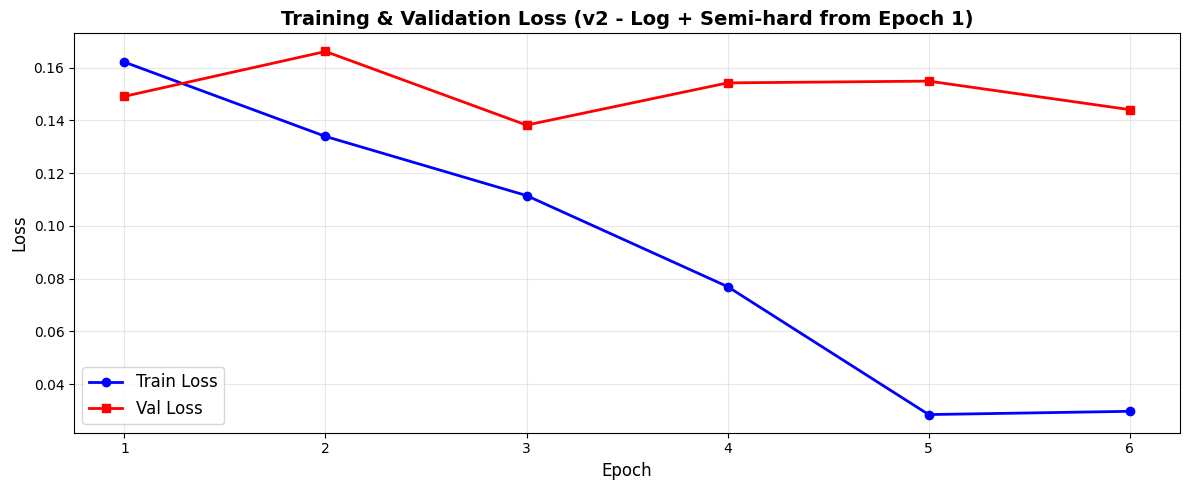


📊 Loss 그래프 저장: /content/drive/MyDrive/Patron/models_v2/training_loss_v2.png


In [13]:
plt.figure(figsize=(12, 5))

plt.plot(range(1, len(train_losses)+1), train_losses,
         marker='o', linewidth=2, label='Train Loss', color='blue')
plt.plot(range(1, len(val_losses)+1), val_losses,
         marker='s', linewidth=2, label='Val Loss', color='red')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training & Validation Loss (v2 - Log + Semi-hard from Epoch 1)', fontsize=14, weight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_PATH}/training_loss_v2.png", dpi=150)
plt.show()

print(f"\n📊 Loss 그래프 저장: {MODEL_SAVE_PATH}/training_loss_v2.png")

최종 Epoch 모델 가중치를 Google Drive에 저장하고 실험 결과를 정리한다. Best 체크포인트와 Loss 그래프가 함께 보관되며, 다음 단계는 07번 노트북에서 실험 1과 시각적 비교를 수행한다.

## 12. 최종 모델 저장

In [14]:
torch.save(model.state_dict(), f"{MODEL_SAVE_PATH}/resnet18_final_v2.pth")

print("="*60)
print("✅ 최종 모델 저장 완료")
print("="*60)
print(f"📁 저장 위치: {MODEL_SAVE_PATH}")
print(f"   - best_model_v2.pth")
print(f"   - resnet18_final_v2.pth")
print(f"   - training_loss_v2.png")
print("="*60)

print("\n🎉 Experiment 3 완료!")
print("\n📝 다음 단계:")
print("   1. patron_readme.md에 결과 기록")
print("   2. 랜덤 쿼리 20개로 검색 성능 테스트")
print("   3. Top-10 중복 종목 개수 확인")

✅ 최종 모델 저장 완료
📁 저장 위치: /content/drive/MyDrive/Patron/models_v2
   - best_model_v2.pth
   - resnet18_final_v2.pth
   - training_loss_v2.png

🎉 Experiment 3 완료!

📝 다음 단계:
   1. patron_readme.md에 결과 기록
   2. 랜덤 쿼리 20개로 검색 성능 테스트
   3. Top-10 중복 종목 개수 확인
